#2η ομαδική εργασία στη Τεχνολογία και Ανάλυση Εικόνων και Βίντεο

## Εισαγωγή και επισκόπηση του συνόλου δεδομένων

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals # legacy compatibility

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# helper functions

# select from from_list elements with index in index_list
def select_from_list(from_list, index_list):#δέχεται ως ορίσματα μία λιστα με τα δεδομένα και μία με αριθμούς
  filtered_list= [from_list[i] for i in index_list] #για κάθε index βρες το αντίστοιχο δεδομένο και βάλτο σε καινούρια λίστα
  return(filtered_list)
#ουσιαστικά με αυτή τη συνάρτηση αν έχω τη λίστα from_list διαλέγω τα στοιχεία με indexes από την index list

# append in filtered_list the index of each element of unfilterd_list if it exists in in target_list
def get_ds_index(unfiliterd_list, target_list):#παίρνει ως ορίσματα τη λίστα με όλα τα δεδομένα και τα στοιχεία που θέλει
  index = 0 #ο μετρητής είναι 0
  filtered_list=[] #δημιουργούμε την κενή λίστα
  for i_ in unfiliterd_list:#για κάθε στοιχείο στη λίστα unfiltered_list
    if i_[0] in target_list:#αν το πρώτο "γράμμα" είναι στο target
      filtered_list.append(index) #βάζουμε το στοιχείο στη filtered_list
    index += 1 # αυξάνουμε το μετρητή και συνεχίζουμε
  return(filtered_list)


In [3]:
# load the entire dataset
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
#παίρνουμε το dataset CIFAR-100 με 60000 εικόνες 32 επί 32 και το χωρίζουμε στις μεταβλητές αυτές για το train (50000) και το test (10000)
(x_train_all, y_train_all), (x_test_all, y_test_all) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [4]:
print(x_train_all.shape)#50000 εικονες για το train και 10000 για το test

(50000, 32, 32, 3)


Η κάθε ομάδα θα δουλέψει με διαφορετικό υποσύνολο του dataset.
Στο επόμενο κελί, αντικαταστήστε την τιμή της μεταβλητής `team_seed` με τον αριθμό που αντιστοιχεί στην ομάδας σας.

In [5]:
# REPLACE WITH YOUR TEAM NUMBER
team_seed = 77 #A.M = 03121077

In [6]:
# select from CIFAR100 20 classes
cifar100_classes_url = "https://pastebin.com/raw/nzE1n98V"

Δημιουργούμε το μοναδικό dataset της ομάδας μας:

In [7]:
import requests
import io

# Δημιουργούμε έναν ψεύτικο "User-Agent" για να μοιάζουμε με κανονικό browser
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# 1. Κατεβάζουμε το πρώτο αρχείο (team_classes)
response1 = requests.get(cifar100_classes_url, headers=headers)
team_classes = pd.read_csv(io.StringIO(response1.text), sep=',', header=None)

# 2. Κατεβάζουμε το δεύτερο αρχείο (CIFAR100_LABELS_LIST)
response2 = requests.get('https://pastebin.com/raw/qgDaNggt', headers=headers)
CIFAR100_LABELS_LIST = pd.read_csv(io.StringIO(response2.text), sep=',', header=None).astype(str).values.tolist()[0]
our_index = team_classes.iloc[team_seed,:].values.tolist()
our_classes = select_from_list(CIFAR100_LABELS_LIST, our_index)
train_index = get_ds_index(y_train_all, our_index)
test_index = get_ds_index(y_test_all, our_index)

x_train_ds = np.asarray(select_from_list(x_train_all, train_index))
y_train_ds = np.asarray(select_from_list(y_train_all, train_index))
x_test_ds = np.asarray(select_from_list(x_test_all, test_index))
y_test_ds = np.asarray(select_from_list(y_test_all, test_index))

In [8]:
# print our classes
print(our_classes)

[' beaver', ' bed', ' beetle', ' bus', ' camel', ' chair', ' crocodile', ' house', ' keyboard', ' lion', ' maple_tree', ' motorcycle', ' mountain', ' porcupine', ' possum', ' shrew', ' snail', ' sunflower', ' trout', ' wolf']


In [9]:
print(x_train_ds[1].shape) #τα δεδομένα μας είναι εικόνες 31 επί 32 με 3 channels

(32, 32, 3)


Train: X=(8500, 32, 32, 3), y=(8500, 1)
Validation: X=(1500, 32, 32, 3), y=(1500, 1)
Test: X=(2000, 32, 32, 3), y=(2000, 1)


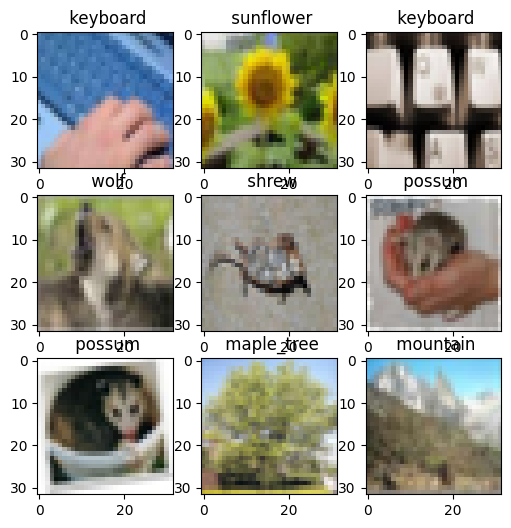

In [10]:
# get (train) dataset dimensions
data_size, img_rows, img_cols, img_channels = x_train_ds.shape

# set validation set percentage (wrt the training set size)
validation_percentage = 0.15 #κραταμε το 15% των δεδομενων για validation, δηλ το 15% του train
val_size = round(validation_percentage * data_size)

# Reserve val_size samples for validation and normalize all values
x_val = x_train_ds[-val_size:]/255 #πάρε τις τελευταιες εικόνες της λίστας και βαλτες στο x_val και κανονικοποιησε τες
y_val = y_train_ds[-val_size:]
x_train = x_train_ds[:-val_size]/255
y_train = y_train_ds[:-val_size]
x_test = x_test_ds/255
y_test = y_test_ds

# summarize loaded dataset
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Validation: X=%s, y=%s' % (x_val.shape, y_val.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))#20 κατηγοριες απο 500 εικονες η καθεμια = 10000 εικονες

# get class label from class index
def class_label_from_index(fine_category):
  return(CIFAR100_LABELS_LIST[fine_category.item(0)])

# plot first few images
plt.figure(figsize=(6, 6))
for i in range(9):
	# define subplot
  plt.subplot(330 + 1 + i).set_title(class_label_from_index(y_train[i]))
	# plot raw pixel data
  plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
  #show the figure
plt.show()

**1. Θεωρητικό Μέρος**

Κατόπιν μελέτης των τριών άρθρων που παρατίθενται από την εκφώνηση της εργασία καταλήγουμε στη σχεδίαση του παρσακάτω πίνακα για την σύκγριση των τριών διαφορετικών δικτύων:


|Χαρακτηριστικά | LeNet| AlexNet | VGGNet |
| :--- | :--- | :--- |:---|
| Επίπεδα | 4 κρυφά επίπεδα | 8 εκπαιδεύσιμα επίπεδα |16 έως 19 επίπεδα|
| Συνάρτηση ενεργοποίησης | Tanh | ReLU |ReLU|
| Μέγεθος φίλτρων | 5x5 | 11x11,5x5,3x3 |3x3|
|Παράμετροι|περίπου 60000|περίπου 60 εκατομμύρια|138 έως 144 εκατομμύρια|
|Dropout|δεν υπάρχει|50% στα fully connected layers|50% στα fully connected layers|
|Pooling|Μέσου όρου με βήμα = 2|Max pooling με overlapping και βήμα = 2|Μax pooling με βήμα = 2|


Το δίκτυο του LeCun ήταν πολύ καινοτόμο για την εποχή του και επειδή περιέχει λίγες εκπαιδεύσιμες παραμέτρους είναι και αρκετά ταχύ. Διατηρούσε ποσοστό σφάλματος 1% και ήταν επιτυχές μόνο σε μικρές ασπρόμαυρες εικόνες. Το AlexNet παρουσίασε σφάλμα 15%, αποδεικνύοντας ότι τα συνελικτικά νευρωνικά δίκτυα μπορούν να αποδώσουν σε έγχρωμες εικόνες υψηλής ανάλυσης με χιλιάδες κατηγορίες. Στην μεγάλη άυξηση της απόδοσής του συνέβαλε η εισαγωγή της συνάρτησης ενεργοποίησης ReLU, η αύξηση των παραμέτρων και η χρήση της τεχνικής Dropout για την αποφυγή του overfitting. Τέλος, το VGGNet, μείωσε ακόμα περισσότερο το ποσοστό σφάλματος σε σύγκριση με το AlexNet καθώς πρόσθεσε περισσότερα επίπεδα στο νευρωνικό δίκτυο αυξάνοντας το βάθος του. Όμως επειδή διαθέτει ακόμα περισσότερες παραμέτρους καταλαμβάνει πολύ χώρο στη μνήμη. Συμπερασματικά, παρατηρόυμε ότι το ένα δίκτυο αποτελέι εξέλιξη του άλλου καθώς το LeNet έβαλε τα θεμέλια της λογικής, το AlexNet δημιούργησε εφαρμογές σε μεγαλύτερη κλίμακα, και το VGGNet τελειοποίησε την αρχιτεκτονική και εισήγαγε την έννοια του βάθους των δικτύων.



## Ερώτημα 1
---
### Βήμα 1: Σχεδίαση και εκπαίδευση των μοντέλων

 Σχεδίαστε και εκπαιδεύστε τα μοντέλα  **LeNet, AlexNet και  VGG**, καθώς και ένα δικό σας μοντέλο (ονομάστε το π.χ. **MyCNN**) χρησιμοποιώντας τον ίδιο αλγορίθμο βελτιστοποίησης ([optimizer](https://keras.io/api/optimizers/)), την ίδια συνάρτηση κόστους [loss function](https://keras.io/api/losses/), το ίδιο μέγεθος παρτίδας (batch size) και 50 εποχές (epochs) `*`.

 Για την εκτίμηση της απόδοσης των μοντέλων να χρησιμοποιήσετε ως μετρική ([metrics](https://keras.io/api/metrics/)) την F1-score.


`*`
 Μπορείτε να πειραματιστείτε με τον optimizer, την loss function και το batch size για τα 4 μοντέλα πριν καταλήξετε στην τελική σας κοινή, για όλα τα μοντέλα επιλογή.


---
  
### Βήμα 2: Αξιολόγηση των μοντέλων

α. Για κάθε ένα από τα μοντέλα που εκπαιδεύσατε στο Βήμα 1, απεικονίστε σε κοινό διάγραμμα τα F1-scores εκπαίδευσης και επικύρωσης στο σύνολο των εποχών.

β. Αξιολογήστε, αναλυτικά, τα αποτελέσματά σας ως προς τα εξής:
 - Επίδραση του πλήθους των δεδομένων/κλάσεων.
 - Επίδραση του αλγόριθμου βελτιστοποίησης (optimizer)
 - Επίδραση του μεγέθους δέσμης (batch size)

---

### Βήμα 3: Αξιολόγηση F1-score
Αξιολογήστε τα F1-scores, χρησιμοποιώντας το σύνολο ελέγχου σας (test set).

---

In [11]:
#ΒΗΜΑ 1
#Πρώτα φέρνω τα δεδμένα στη μορφή που αποδέχεται το Νευρωνικό δίκτυο
import numpy as np
import tensorflow as tf

mapping = {old_label: new_label for new_label, old_label in enumerate(our_index)}#our_index = ο αριθμός της κατηγορίας
#ουσιαστικά παίρνουμε τα old_labels τη σειρά και τα ονομάζουμε από το 0 έως το 19
#ο υπολογιστής δεν καταλαβαίνει κείμενο

def map_labels(y_dataset):
    return np.array([mapping[label.item()] for label in y_dataset])
#η map_labels παίρνει μία μία τις ετικέτες από το y_dataset και τις αντικαθιστά με το new_label και
#το μετατρέπει σε πίνακα για να μπορεί να το διαχειριστεί το νευρωνικό
#καλούμε τη συνάρτηση για το y_train, y_val και

y_train_mapped = map_labels(y_train)
y_val_mapped = map_labels(y_val)
y_test_mapped = map_labels(y_test)

#τα μετατρέπουμε σε 0 και 1 με one hot encoding
y_train_onehot = tf.keras.utils.to_categorical(y_train_mapped, num_classes=20)
y_val_onehot = tf.keras.utils.to_categorical(y_val_mapped, num_classes=20)
y_test_onehot = tf.keras.utils.to_categorical(y_test_mapped, num_classes=20)

#η νέα διάσταση ειναι 8500, 20 γιατι έχει 1 μόνο στην κατηγορία στην οποία ανήκει
print('Νέα διάσταση y_train_onehot:', y_train_onehot.shape)

Νέα διάσταση y_train_onehot: (8500, 20)


In [12]:
from tensorflow.keras import layers, models

def Lenet():
    model = models.Sequential()

    #1ο Συνελικτικό επίπεδο με είσοδο (32,32,3) και έξοδο (28,28,6)
    model.add(layers.Conv2D(filters=6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    #1ο Επίπεδο pooling με έξοδο (14,14,6)
    model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=2))

    #2ο Συνελικτικό επίπεδο με έξοδο (10,10,16)
    model.add(layers.Conv2D(filters=16, kernel_size=(5, 5), activation='tanh'))
    model.add(layers.BatchNormalization())
    #2ο Επίπεδο pooling με έξοδο (5,5,16)
    model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=2))

    #Επιπεδοποίηση
    model.add(layers.Flatten())# η είσοδος στους επόμενους νευρώνες είναι μονοδιάστατη και ίση με 400

    #1ο fully connected layer με έξοδο (120)
    model.add(layers.Dense(120, activation='tanh'))

    #2ο fully connected layer me έξοδο (84)
    model.add(layers.Dense(84, activation='tanh'))

    #Επίπεδο εξόδου με 20 νευρώνες όσους και οι κλάσεις
    model.add(layers.Dense(20, activation='softmax'))

    return model

#Δημιουργούμε το μοντέλο ξανά
lenet_model = Lenet()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
def Alexnet():
    #η εντολή αυτή δημιουργεί ένα κενό νευρωνικό δίκτυο που τα επίπεδα μπαίνουν με τη σειρά
    model = models.Sequential()

    #1ο συνελικτικό επίπεδο
    #προσθέτουμε padding και θέτουμε stride = 1 για να μην μικρύνει πολύ η εικόνα (32,32,96) #κανονικα το φιλτρο ηταν 11 επι 11 αλλα δεν εβγαινε
    model.add(layers.Conv2D(filters=96, kernel_size=(3, 3), strides=1, padding='same', activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())#κανονικοποιούμε για να τα φέρουμε όλα στην ίδια κλιμακα
    #2ο επίπεδο με max pooling και βήμα 2 άρα εχω έξοδο (Είσοδος - Παράθυρο) / Βήμα + 1 = (32-3)/2 +1 = 15,5 -> (15,15,96)
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=2))

    #2ο συνελικτικό επίπεδο με έξοδο (15,15,256)
    model.add(layers.Conv2D(filters=256, kernel_size=(5, 5), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    #έξοδος του επιπέδου pooling 7,7,256
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=2))

    #3ο συνελικτικό επίπεδο χωρίς pooling
    model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    #4ο συνελικτικό επίπεδο χωρίς pooling
    model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    #5ο συνελικτικό επίπεδο χωρίς pooling
    model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())#έξοδος (7,7,256)

    #Τελικό Pooling του μπλοκ εξαγωγής χαρακτηριστικών (3,3,256)
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=2))
    model.add(layers.Flatten())#2304 στοιχεία μετά την επιπεδοποίηση

    #fully connected layers
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(512, activation='relu')) #κανονικα ηταν 4096 γιατι εχω λιγες κλασεις
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    #Επίπεδο Εξόδου -έχουμε 20 κατηγορίες άρα και 20 νευρώνες
    model.add(layers.Dense(20, activation='softmax'))

    return model

#Δημιουργούμε το μοντέλο
alexnet_model = Alexnet()

In [14]:
def VGG16():
    model = models.Sequential()

    #1ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())

    #2ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2)) #16,16,64

    # 3ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    # 4ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))#8,8,128

    # 5ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    # 6ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    # 7ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))#4,4,256

    # 8ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    # 9ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    # 10ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2)) #2,2,512

    # 11ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    # 12ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())

    # 13ο Συνελικτικό επίπεδο
    model.add(layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))#1,1,512

    #flattening
    model.add(layers.Flatten())#512

    #1o fully connected layer
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    #2o fully connected layer
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    #output
    model.add(layers.Dense(20, activation='softmax'))

    return model

# Δημιουργώ το μοντέλο
vgg16_model = VGG16()

In [15]:
def Mycnn():
    model = models.Sequential(name="MyCNN")

    #1o συνελικτικό επίπεδο με 32 χάρτες χαρακτηριστικών
    model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    #1ο pooling επίπεδο με έξοδο (16,16,32)
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))#αυτόματα stride = 2

    #2ο συνελικτικό επίπεδο με 64 χάρτες χαρακτηριστικών για εξαγωγή πιο σύνθετων χαρακτηριστικών
    model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))#έξοδος (8,8,64)

    #3ο συνελικτικό επίπεδο με 128 χάρτες χαρακτηριστικών
    model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))#έξοδος (4,4,128)

    #επιπεδοποίηση 2048 δεδομένα
    model.add(layers.Flatten())

    #1ο fully connected layer
    model.add(layers.Dense(256, activation='relu'))#έξοδος = 256
    #προσθέτω dropout για να μην έχω overfitting
    model.add(layers.Dropout(0.5))

    #Στην έξοδο έχω 20 κατηφορίες άρα 20 νευρώνες
    model.add(layers.Dense(20, activation='softmax'))
    return model

#Δημιουργώ το μοντέλο
mycnn_model = Mycnn()


In [16]:
#Training
batch_size = 64 #κάθε 64 εικόνες αλλάζουμε τα βάρη
epochs = 50 #μία εποχή βλέπει όλες τις εικόνες από μία φορά
lr = 0.0001 #ο ρυθμός μάθησης

#Επιλέγω ως optimizer τον Adam γιατί ξεπερνάει πιο εύκολα τα τοπικά ελάχιστα
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
loss = tf.keras.losses.CategoricalCrossentropy()
f1_score = tf.keras.metrics.F1Score(average='macro', name='f1_score')

#επειδή έχω να εκπαιδεύσω 4 μοντέλα φτιάχνω συνάρτηση
def train_model(model, model_name):
    print(f"Ξεκινάει η εκπαίδευση του {model_name}")
#compiler των μοντέλων
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')]
    )
#fit
    history = model.fit(
        x_train, y_train_onehot,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_val, y_val_onehot),
        verbose=1#εμφανίζεται η μπάρα φόρτωσης
    )
    return history

#train
history_lenet = train_model(lenet_model, "LeNet")
history_alexnet = train_model(alexnet_model, "AlexNet")
history_vgg = train_model(vgg16_model, "VGG")
history_mycnn = train_model(mycnn_model, "MyCNN")



Ξεκινάει η εκπαίδευση του LeNet
Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.1481 - f1_score: 0.1238 - loss: 2.8138 - val_accuracy: 0.1680 - val_f1_score: 0.1276 - val_loss: 2.7323
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2468 - f1_score: 0.2085 - loss: 2.5114 - val_accuracy: 0.2533 - val_f1_score: 0.2271 - val_loss: 2.5124
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2880 - f1_score: 0.2590 - loss: 2.3973 - val_accuracy: 0.2880 - val_f1_score: 0.2623 - val_loss: 2.4025
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3204 - f1_score: 0.2962 - loss: 2.3220 - val_accuracy: 0.3127 - val_f1_score: 0.2924 - val_loss: 2.3305
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3425 - f1_score: 0.3214 - loss: 2.2625 - val_accuracy: 0.3193 - val_f1_score: 0.3014 - val_loss: 2.2926
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3611 - f1_score: 0.3434 - loss: 2.2091 - val_accur

In [17]:
#ΒΗΜΑ 2, βρίσκω τα μεγιστα validaion f1 scores κατά τη διάρκεια της εκπαίδευσης
import numpy as np

histories = {
    "LeNet": history_lenet,
    "AlexNet": history_alexnet,
    "VGG": history_vgg,
    "MyCNN": history_mycnn
}

print("Μέγιστο Validation F1-Score ανά Μοντέλο")
for name, history in histories.items():
    best_f1 = np.max(history.history['val_f1_score'])
    best_epoch = np.argmax(history.history['val_f1_score']) + 1
    print(f"{name}: {best_f1:.4f} (επιτεύχθηκε στην εποχή {best_epoch})")

Μέγιστο Validation F1-Score ανά Μοντέλο
LeNet: 0.4300 (επιτεύχθηκε στην εποχή 42)
AlexNet: 0.6958 (επιτεύχθηκε στην εποχή 22)
VGG: 0.5986 (επιτεύχθηκε στην εποχή 49)
MyCNN: 0.6088 (επιτεύχθηκε στην εποχή 46)


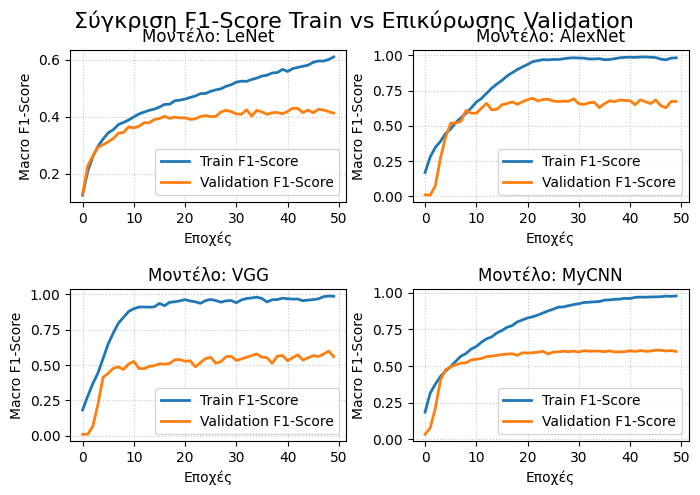

In [18]:
#Φτιάχνω τα γραφήματα train vs validation
import matplotlib.pyplot as plt
#Φτιάχνω 4 γραφήματα, ένα  για κάθε μοντέλο
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
fig.suptitle('Σύγκριση F1-Score Train vs Επικύρωσης Validation', fontsize=16)
#τα βάζουμε σε μία λίστα
models_info = [
    ('LeNet', history_lenet, axes[0, 0]),
    ('AlexNet', history_alexnet, axes[0, 1]),
    ('VGG', history_vgg, axes[1, 0]),
    ('MyCNN', history_mycnn, axes[1, 1])
]

for name, history, ax in models_info:
    ax.plot(history.history['f1_score'], label='Train F1-Score', linewidth=2)
    ax.plot(history.history['val_f1_score'], label='Validation F1-Score', linewidth=2)
    ax.set_title(f'Μοντέλο: {name}')
    ax.set_xlabel('Εποχές')
    ax.set_ylabel('Macro F1-Score')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

**Επίδραση του πλήθους των δεδομένων και των κλάσεων**

Σύμφωνα με την εκφώνηση διαλέγουμε μόνο 20 κλάσεις από το CIFAR-100, γεγονός που σημαίνει ότι έχουμε 500 εικόνες ανά κλάση. Επίσης οι εικόνες που διαθέτουμε είναι πολύ μικρότερες από αυτές για τις οποίες σχεδιάστηκαν τα συγκεκριμένα νευρωνικά δίκτυα. Ο μικρός όγκος δεδομένων οδηγεί σε καλύτερα αποτελέσματα, ωστόσο μπορούν να προκαλέσουν και overfitting. Για το λόγο αυτό επιστρατεύσαμε τεχνικές όπως το dropout και η κανονικοποίηση.

**Επίδραση του optimizer**

Χρησιμοποιήσαμε τον αλγόριθμο Adam. Ο Adam είναι προσαρμόζει δυναμικά τον ρυθμό εκμάθησης για κάθε ένα βάρος ξεχωριστά, χρησιμοποιώντας πληροφορίες από προηγούμενες κλίσεις. Όπως φάνηκε, τα μοντέλα χρειάστηκαν μόλις 40-50 εποχές για να πιάσουν τη μέγιστη απόδοσή τους. Αν είχαμε επιλέξει διαφορετικό αλγόριθμο βελτιστοποίησης πιθανόττατα θα χρειάζονταν περισσότερες εποχές για να προσεγγίσουμε τα ίδια αποτελέσματα.

**Επίδραση του μεγέθους του batch**

Το batch size 64 είναι το μέγεθος που επιλέξαμε. Μικρότερο μέγεθος θα καθυστερούσε πολύ την εκπαίδευση. Αν είχαμε διαλέξει πολύ μεγάλο batch size, ο υπολογισμός της κλίσης θα ήταν πολύ ακριβής, αλλά το μοντέλο θα κινδύνευε να παγιδευτεί σε τοπικά ελάχιστα. Αυτός ο θόρυβος λειτουργεί ως μια φυσική μορφή κανονικοποίησης, βοηθώντας τα μοντέλα να ξεφύγουν από τοπικά ελάχιστα και να γενικεύσουν καλύτερα στα άγνωστα δεδομένα.



In [19]:
#BHMA 3-Αξιολόγηση του τεστ
models_dict = {
    "LeNet": lenet_model,
    "AlexNet": alexnet_model,
    "VGG": vgg16_model,
    "MyCNN": mycnn_model
}#δημιουργώ ένα λεξικό με όλα τα μοντέλα

print("Αξιολόγηση Μοντέλων στο Test Set\n")

for name, model in models_dict.items():#για κάθε μοντέλο στο λεξικό αυτό
    results = model.evaluate(x_test, y_test_onehot, verbose=0)#η results περιέχει το σφάλμα, την ακρίβεια και το f1 score
    test_loss = results[0]
    test_acc = results[1]
    test_f1 = results[2]

    print(f"{name}")
    print(f"Test F1-Score : {test_f1:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(f"Test Loss     : {test_loss:.4f}\n")

Αξιολόγηση Μοντέλων στο Test Set

LeNet
Test F1-Score : 0.4224
Test Accuracy : 0.4215
Test Loss     : 1.9324

AlexNet
Test F1-Score : 0.6703
Test Accuracy : 0.6650
Test Loss     : 1.6105

VGG
Test F1-Score : 0.5678
Test Accuracy : 0.5685
Test Loss     : 2.7269

MyCNN
Test F1-Score : 0.5966
Test Accuracy : 0.5990
Test Loss     : 1.6397




## Ερώτημα 2
---
### Βήμα 1: Έλεγχος υπερεκπαίδευσης

Για μοντέλο σας  (**MyCNN**) και μόνο, δοκιμάστε διάφορους συνδυασμούς των ακόλουθων τεχνικών για τον έλεγχο της υπερεκπαίδευσης (overfitting), ώστε το μοντέλο σας να γενικεύει καλύτερα, όπως:

- Dropout ([Dropout](https://www.tensorflow.org/tutorials/images/classification#dropout))

- Επαύξηση δεδομένων ([Data augmentation](https://www.tensorflow.org/tutorials/images/classification#data_augmentation), [ImageDataGenerator](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator#class_imagedatagenerator))

---
### Βήμα 2: Αξιολόγηση
Αξιολογήστε τα αποτελέσματά σας, βάσει του F1 score για το σύνολο επικύρωσης και για το σύνολο ελέγχου

---


In [20]:
#Ερώτημα 2
#Βήμα 1
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#το data augmentation ουσιαστικά αλλάζει τυχαία τις εικόνες για να μειώσουμε το overfitting
datagen = ImageDataGenerator(
    rotation_range=10,      #Περιστρέφουμε τις εικόνες το πολύ κατά 10 μοίρες τυχαία
    width_shift_range=0.1,  #οριζόντια μετατόπιση κατά 10%
    height_shift_range=0.1, #κάθετη μετατόπιση κατά 10%
    horizontal_flip=True,   #καθρέφτισμα
    zoom_range=0.1          #μεγέθυνση
)

mycnn_better_model = Mycnn()

#στο compile δίνουμε τους κανόνες
mycnn_better_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),#ο αλγόριθμος που καθορίζει την κατεύθυνση και την ταχύτητα που αλλάζουν τα βάρη
    loss=tf.keras.losses.CategoricalCrossentropy(),#ο τρόπος υπολογισμού του σφάλματος
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')]#οι μετρικές αξιολόγησης είναι το f1 και το accuracy
)

print("Ξεκινάει η εκπαίδευση με Data Augmentation γιατί είχα ήδη dropout")

history_mycnn_better = mycnn_better_model.fit(
    datagen.flow(x_train, y_train_onehot, batch_size=batch_size),#περνάμε τις εικόνες από το datagen για αποφυγή overfitting
    epochs=epochs,#εποχές = 50
    validation_data=(x_val, y_val_onehot)#στο τέλος κάθε εποχής έχω το validation
)


Ξεκινάει η εκπαίδευση με Data Augmentation γιατί είχα ήδη dropout
Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.1821 - f1_score: 0.1743 - loss: 3.0596 - val_accuracy: 0.0533 - val_f1_score: 0.0192 - val_loss: 3.3468
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.2727 - f1_score: 0.2624 - loss: 2.4144 - val_accuracy: 0.0840 - val_f1_score: 0.0560 - val_loss: 3.4016
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.3140 - f1_score: 0.3063 - loss: 2.2787 - val_accuracy: 0.2433 - val_f1_score: 0.2303 - val_loss: 2.4864
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.3440 - f1_score: 0.3371 - loss: 2.1658 - val_accuracy: 0.3833 - val_f1_score: 0.3739 - val_loss: 2.0116
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.3726 - f1_score: 0.3660 - loss: 2.0929 - val_accuracy: 0.4440 - val_f1_score: 0.4320 - val_loss: 1.8450
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.3873 - f1_s

In [21]:
#βρίσκουμε το μέγιστο validation score και σε ποια εποχή το πετύχαμε
best_val_f1_better = np.max(history_mycnn_better.history['val_f1_score'])
#πάρε από τη στήλη val_f1_score τη μέγιστη τιμή
best_epoch_better = np.argmax(history_mycnn_better.history['val_f1_score']) + 1
#βρίσκει σε ποια εποχή πετύχαμε αυτό το σκορ και προσθέτει 1 για το ανθρώπινο μυαλό

print(f"Βελτιωμένο MyCNN - Μέγιστο Validation F1-Score: {best_val_f1_better:.4f} (στην εποχή {best_epoch_better})")

Βελτιωμένο MyCNN - Μέγιστο Validation F1-Score: 0.6372 (στην εποχή 49)


In [22]:
#Αξιολογούμε το μοντέλο στο test set
print("Αξιολόγηση του βελτιωμένου MyCNN στο Test Set")
results_better = mycnn_better_model.evaluate(x_test, y_test_onehot, verbose=0)
print(f"Test F1-Score : {results_better[2]:.4f}")

Αξιολόγηση του βελτιωμένου MyCNN στο Test Set
Test F1-Score : 0.6047


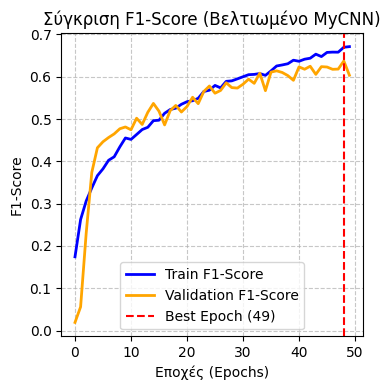

In [31]:
import matplotlib.pyplot as plt

# Ορίζουμε το μέγεθος του συνολικού γραφήματος
plt.figure(figsize=(7, 4))
plt.subplot(1, 2, 1)
plt.plot(history_mycnn_better.history['f1_score'], label='Train F1-Score', color='blue', linewidth=2)
plt.plot(history_mycnn_better.history['val_f1_score'], label='Validation F1-Score', color='orange', linewidth=2)
plt.axvline(x=best_epoch_better - 1, color='red', linestyle='--', label=f'Best Epoch ({best_epoch_better})')
plt.title('Σύγκριση F1-Score (Βελτιωμένο MyCNN)')
plt.xlabel('Εποχές (Epochs)')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Ερώτημα 3
---
### Βήμα 1: Μεταφορά γνώσης
Εφαρμόστε μεταφορά γνώσης (transfer learning) στο δικό σας μοντέλο (**MyCNN**), που αξιολογήσατε ως καλύτερο προς το F1 score στην αντιμετώπιση της υπερεκπαίδεσης.

Για το transfer learning, επιλέξτε το [VGG19](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19)  και το [EfficientNetB0](https://www.tensorflow.org/api_docs/python/tf/keras/applications/efficientnet/EfficientNetB0) για μεταφορά μάθησης.

α. "Παγώστε" τη συνελικτική βάση και εκπαιδεύστε την κεφαλή ταξινόμησης (classification head - σημαία trainable = False).  

β. Εκπαιδέστε μόνο ένα ποσοστό των επιπέδων, το οποίο βρίσκεται προς την έξοδο του δικτύου. Οι σημαίες trainable εδώ θα πρέπει να οριστούν ανά επίπεδο.

---
### Βήμα 2: Αξιολόγηση

Αξιολογήστε τα αποτελέσματά σας, βάσει του F1 score για το σύνολο επικύρωσης και για το σύνολο ελέγχου.

---

In [23]:
#Ερώτημα 3
#ΒΗΜΑ 1
#ΞΕΚΙΝΑΜΕ ΜΕ ΤΟ VGG19
from tensorflow.keras.applications import VGG19
print(" Δημιουργία Μοντέλου VGG19 (Transfer Learning) ")

#παίρνουμε ως βάση το έτοιμο VGG19 που έχει εκπαιδευτεί από τη google και αφαιρούμε το τέλος για
#να κολλήσουμε το δικό μου MyCNN
base_model_vgg = VGG19(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model_vgg.trainable = False#δεν αλλάζουμε τα βάρη του προεκπαιδευμένου μοντέλου

model_vgg_tl = models.Sequential([
    base_model_vgg,
    layers.Flatten(),#κραταμε μονο τα fully connected layers του mycnn
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(20, activation='softmax')
])


base_model_vgg.trainable = True#ξεπαγώνουμε το ήδη εκπαιδευμένο κομμάτι

for layer in base_model_vgg.layers[:17]:#αφήνουμε εκπαιδεύσιμο μόνο το τελυταίο μπλοκ
    layer.trainable = False

print("Ελέγχουμε ποια επίπεδα είναι εκπαιδεύσιμα:")
for i, layer in enumerate(base_model_vgg.layers):#παίρνουμε όλα τα επίπεδα του μοντέλου και τα ελέγχω ένα ένα
    print(f"Layer {i}: {layer.name} - Trainable: {layer.trainable}")#αν είναι trainable τυπώνει true δηλ τα βάρη του αλλάζουν

model_vgg_tl.compile(#κανουμε πάλι το compile του μοντέλου
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')]
)


 Δημιουργία Μοντέλου VGG19 (Transfer Learning) 
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Ελέγχουμε ποια επίπεδα είναι εκπαιδεύσιμα:
Layer 0: input_layer_5 - Trainable: False
Layer 1: block1_conv1 - Trainable: False
Layer 2: block1_conv2 - Trainable: False
Layer 3: block1_pool - Trainable: False
Layer 4: block2_conv1 - Trainable: False
Layer 5: block2_conv2 - Trainable: False
Layer 6: block2_pool - Trainable: False
Layer 7: block3_conv1 - Trainable: False
Layer 8: block3_conv2 - Trainable: False
Layer 9: block3_conv3 - Trainable: False
Layer 10: block3_conv4 - Trainable: False
Layer 11: block3_pool - Trainable: False
Layer 12: block4_conv1 - Trainable: False
Layer 13: block4_conv2 - Trainable: False
Layer 14: block4_conv3 - Trainable: False
Layer 15: block4_conv4 - Trainable: False
Layer 16: block4_pool - Trainable: False
Layer 17: block5_conv1 - Trainable: True
Layer 18: block5_conv2 - Trainable: True
Layer 19: block5_conv3 - Trainable: True
Layer 20: block5_conv4 - Trainable

In [24]:
#ΣΥΝΕΧΙΖΟΥΜΕ ΜΕ ΤΟ EfficientNetB0
from tensorflow.keras.applications import EfficientNetB0

print("EfficientNetB0 με Μεγεθυντικό Φακό")

#Όπως και πριν βάζουμε το ήδη εκπαιδευμένο αφαιρουμε το τοπ επίπεδο για να προσθέσω το δικό μας
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
#αλλάξαμε την είσοδο σε (96,96,3) θα κάνουμε resizing
base_model_eff.trainable = False #παγώνουμε τα επίπεδα

model_eff_tl = models.Sequential([
    layers.Rescaling(scale=255.0, input_shape=(32, 32, 3)), #πολλαπλασιάζω τις τιμές με το 255 γιατί ηταν κανονικοποιημένες
    layers.Resizing(96, 96), #μεγαλώνω το μέγεθος της εικόνας γιατί το συγκεκριμένο δίκτυο έχει πολλά επίπεδα και τη μικραίνει πολύ
    base_model_eff,#βάζουμε το προεκπαιδευμένο επίπεδο
    #προσθέτω τα τελικά επίπεδα του δικού μου MyCNN
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(20, activation='softmax')
])

model_eff_tl.compile(#κάνουμε το compile
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),#με τον Adam
    loss=tf.keras.losses.CategoricalCrossentropy(),#το σφάλμα
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')]#και τα κριτήρια αξιολόγησης
)

print("Εκπαίδευση Phase 1")
#ουσιαστικά εκπαιδεύουμε μόνο το κεφάλι του δικτύου που προσθέσαμε
history_phase1 = model_eff_tl.fit(
    x_train, y_train_onehot,
    batch_size=64,
    epochs=5,
    validation_data=(x_val, y_val_onehot)
)

print("\nΕκπαίδευση Phase 2")
base_model_eff.trainable = True#ξεπαγώνουμε και τη βάση

for layer in base_model_eff.layers[:-30]:#παίρνω όλα τα επίπεδα μέχρι πριν τα 30 τελευταία
    layer.trainable = False#και τα παγώνω

for layer in base_model_eff.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False#προστατευω τα επίπεδα της κανονικοποίησης

model_eff_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), #μικραίνω το ρυθμό εκμάθησης
    loss=tf.keras.losses.CategoricalCrossentropy(),#όλα τα υπόλοιπα τα κρατάω ίδια
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')]
)

print("Εκπαίδευση Phase 2")
history_phase2 = model_eff_tl.fit(
    x_train, y_train_onehot,
    batch_size=64,
    epochs=10, #συνεχίζω την εκπαιδευση
    validation_data=(x_val, y_val_onehot)
)

EfficientNetB0 με Μεγεθυντικό Φακό
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Εκπαίδευση Phase 1
Epoch 1/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 65s 284ms/step - accuracy: 0.6766 - f1_score: 0.6756 - loss: 1.1169 - val_accuracy: 0.8267 - val_f1_score: 0.8251 - val_loss: 0.5769
Epoch 2/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8154 - f1_score: 0.8152 - loss: 0.5982 - val_accuracy: 0.8347 - val_f1_score: 0.8324 - val_loss: 0.5336
Epoch 3/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8492 - f1_score: 0.8491 - loss: 0.4768 - val_accuracy: 0.8387 - val_f1_score: 0.8356 - val_loss: 0.5162
Epoch 4/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8778 - f1_score: 0.8777 - loss: 0.3929 - val_accuracy: 0.8407 - val_f1_score: 0.8391 - val_loss: 0.5143
Epoch 5/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8927 - f1_score: 0.8929 - loss: 0.3414 - val_accuracy: 0.8433 - val_f1_score: 0.8415 - val_loss: 0.5076

Εκπαίδευση Phase 2
Εκπαίδευση Phase 2
Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 55s 224ms/step - accuracy: 0.9148 - f1_score: 0.91

In [25]:
#κάνω την αξιολόγηση του EfficientNetB0 στο test set
print("Τελική Αξιολόγηση EfficientNetB0 στο Test Set")
results_eff = model_eff_tl.evaluate(x_test, y_test_onehot, verbose=1)
print("\nΤελικά Αποτελέσματα")
print(f"Test Loss:     {results_eff[0]:.4f}")
print(f"Test Accuracy: {results_eff[1]:.4f}")
print(f"Test F1-Score: {results_eff[2]:.4f}")

Τελική Αξιολόγηση EfficientNetB0 στο Test Set
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step - accuracy: 0.8440 - f1_score: 0.8443 - loss: 0.5201

Τελικά Αποτελέσματα
Test Loss:     0.5201
Test Accuracy: 0.8440
Test F1-Score: 0.8443


In [26]:
print("Ξεκινάει η εκπαίδευση του VGG19 (Transfer Learning)")
epochs_tl = 15 #αν βαζαμε πολλές εποχές επειδη δεν τις χρειάζεται θα είχαμε overfitting

history_vgg = model_vgg_tl.fit(
    x_train, y_train_onehot,
    batch_size=batch_size,
    epochs=epochs_tl,
    validation_data=(x_val, y_val_onehot)
)

Ξεκινάει η εκπαίδευση του VGG19 (Transfer Learning)
Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.3508 - f1_score: 0.3405 - loss: 2.1523 - val_accuracy: 0.5680 - val_f1_score: 0.5436 - val_loss: 1.4805
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5548 - f1_score: 0.5499 - loss: 1.4619 - val_accuracy: 0.6060 - val_f1_score: 0.5943 - val_loss: 1.2857
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6498 - f1_score: 0.6469 - loss: 1.1409 - val_accuracy: 0.6440 - val_f1_score: 0.6367 - val_loss: 1.1519
Epoch 4/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7075 - f1_score: 0.7060 - loss: 0.9399 - val_accuracy: 0.6693 - val_f1_score: 0.6668 - val_loss: 1.1144
Epoch 5/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7714 - f1_score: 0.7705 - loss: 0.7443 - val_accuracy: 0.6833 - val_f1_score: 0.6807 - val_loss: 1.1161
Epoch 6/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8069 - f1_score: 0.8068 -

In [27]:
#Αξιολόγηση του VGG στο test set
print("Αξιολόγηση VGG19")
results_vgg = model_vgg_tl.evaluate(x_test, y_test_onehot, verbose=0)
print(f"VGG19 - Test F1-Score: {results_vgg[2]:.4f}")

Αξιολόγηση VGG19
VGG19 - Test F1-Score: 0.6610


Συμπερασματικά, παρατηρούμε ότι το νευρωνικό δίκτυο LeNet επειδή είναι παλαιότερο, πιο ρηχό και με λιγότερες παραμέτρους έχει τα χειρότερα αποτελέσματα. Το Alexnet παρουσιάστηκε ως εξέλιξη του LeNet και έχει σαφώς καλύτερα αποτελέσματα αλλά νικητης ειναι το Vgg διότι εχει πολλες περισσοτερες παραμετρους, dropout κλπ. To δικο μου Cnn είναι συνδυασμος των παραπανω και απολυτα προσαρμοσμένο στις απαιτήσεις του δοθέντος dataset. Συμπερασματικά, η συγκριτική αξιολόγηση των μοντέλων αναδεικνύει ξεκάθαρα τη σημασία του βάθους και της πολυπλοκότητας στην αρχιτεκτονική των συνελικτικών νευρωνικών δικτύων. Όσο αφορά τα προεκπαιδευμένα μοντέλα EfficientNet και VGG19, συμπεραίνουμε ότι επειδή είναι προεκπαιδευμένα σε μεγάλα dataset της google είναι πολύ πιο αποτελεσματικά. Το EfficientNet είναι πιο σύγχρονο από το VGG19 και παρόλο που είναι πιο ελαφρύ και έχει λιγότερες παραμέτρους επιτυγχάνει μεγαλύτερη ακρίβεια και γενίκευση.


## Διαχείριση μνήμης (TFRecord)
Η φόρτωση δεδομένων με τον τρόπο που το κάναμε παραπάνω στο απλό παράδειγμα υλοποίησης είναι πολύ βολική αλλά δεν είναι αποτελεσματική ως προς τη διαχείριση της μνήμης. Συγκεκριμένα, με τον τρόπο αυτό, τα δεδομένα αποθηκεύονται απευθείας σε μεταβλητές, οι οποίες όλες μαζί καταλαμβάνουν τη RAM της CPU ή της GPU, κάτι που κάνει αδύνατη τη διαχείριση μεγάλων datasets ή τον μεταχηματισμό των δεδομένων όπως όταν κάνουμε αύξηση δεδομένων (data augmentation).

Για να παρακαμφθεί αυτό το πρόβλημα, υπάρχει η δυνατότητα της σειριοποίησης των δεδομένων (serialization) και της αποθήκευσής τους σε αρχεία μεσαίου μεγέθους (κάποιων MB) τα οποία μπορούν να αναγνωστούν γραμμικά.

Το φορμάτ TFRecord είναι ένα φορμάτ που επιτρέπει την αποθήκευση σειράς δυαδικών εγγραφών. Διαβάστε σχετικά για το [TFRecord and tf.Example](https://www.tensorflow.org/tutorials/load_data/tfrecord) και [tf.data: Build TensorFlow input pipelines](https://www.tensorflow.org/guide/data).

Σημειώστε ότι με τη μέθοδο αυτή θα πρέπει να γίνει import η `tensorflow_datasets` και να χρησιμοποιήσουμε την `tfds.load` ώστε να αποθηκευθεί το σύνολο δεδομένων σε αρχεία tfrecord στο δίσκο (δείτε [εδώ](https://colab.research.google.com/github/tensorflow/datasets/blob/master/docs/overview.ipynb) ένα παράδειγμα). Φυσικά μπορούμε να μετατρέψουμε και τα πρωτογενή δεδομένα (raw data) του dataset όπως αρχεία jpg σε φορματ tfrecord όπως [εδώ](https://towardsdatascience.com/working-with-tfrecords-and-tf-train-example-36d111b3ff4d).
